# Fit shell parameters to radius curves

Estimate the elasticity and the dilatational viscosity of a lipid shell from noisy radius-time curves recorded at three driving pressures. In this example, you declare the unknowns with `Parameter` bounds, fit all three recordings at once with `fit_parameters`, and look at the loss landscape that the optimiser walks across.

In [ ]:
# Install jbubble on Google Colab, or anywhere it's missing.
import importlib.util

if importlib.util.find_spec("jbubble") is None:
    %pip install --quiet "jbubble[examples]==0.2.0"

In [1]:
import os
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from jbubble import SaveSpec, fit_parameters, run_simulation
from jbubble.fitting import Parameter
from jbubble.metrics import normalised_mse_radius
from jbubble.utils import GridSweep
from jbubble.utils.presets import lipid_bubble

plt.style.use("jbubble.style.light")

# Set JBUBBLE_QUICK=1 for a fast, coarse run (used by CI).
QUICK = os.environ.get("JBUBBLE_QUICK") == "1"

## Make stand-in measurements

In a real study, an ultra-high-speed camera records the radius of one bubble at several driving pressures. Here, the [`lipid_bubble`](https://imperial-nsb.github.io/jbubble/api/utils/#jbubble.utils.presets.lipid_bubble) preset plays the bubble: a 2 µm SF6 bubble with a smoothed Marmottant lipid shell, driven by a five-cycle 1 MHz tone burst. Its shell elasticity `chi` and dilatational viscosity `kappa_s` are the values to recover. Gaussian noise of 20 nm, 1 % of the radius, stands in for the camera's measurement error.

In [2]:
R0 = 2e-6  # equilibrium radius, measured optically [m]
PRESSURES = [50e3, 100e3, 150e3]  # peak driving pressures [Pa]
NOISE = 20e-9  # radius measurement noise, one standard deviation [m]
TRUE = {"chi": 0.5, "kappa_s": 7.5e-9}  # [N/m], [N s/m]
SAVE_SPEC = SaveSpec(256)
T_MAX = 8e-6  # [s]

key = jax.random.PRNGKey(0)
conditions = []
for i, pressure in enumerate(PRESSURES):
    eom, pulse = lipid_bubble(R0=R0, pressure=pressure, **TRUE)
    clean = run_simulation(eom, pulse, save_spec=SAVE_SPEC, t_max=T_MAX).radius
    noise = NOISE * jax.random.normal(jax.random.fold_in(key, i), clean.shape)
    conditions.append({"pressure": pressure, "radius": clean + noise})
    print(f"{pressure / 1e3:5.0f} kPa: R_max/R0 = {float(clean.max()) / R0:.2f}")

   50 kPa: R_max/R0 = 1.05


  100 kPa: R_max/R0 = 1.23


  150 kPa: R_max/R0 = 1.56


## Describe the model and the loss

[`fit_parameters`](https://imperial-nsb.github.io/jbubble/api/fitting/#jbubble.fitting.fit_parameters) needs two functions. Both receive one entry of `conditions`, that is, one recording, as their second argument:

- `make_model(params, condition)` returns the `(eom, pulse)` pair to simulate. `lipid_bubble` returns exactly such a pair, so the preset is the whole model.
- `loss_fn(result, condition)` compares the simulation with the recording. [`normalised_mse_radius`](https://imperial-nsb.github.io/jbubble/api/metrics/#jbubble.metrics.normalised_mse_radius) divides the mean squared error by $R_0^2$, so the loss is dimensionless. With a perfect model, it settles at the noise level, $(\sigma_\text{noise}/R_0)^2 = 10^{-4}$.

`fit_parameters` averages the loss over the recordings. Recordings at several pressures constrain the shared shell parameters far better than one recording does.

In [3]:
def make_model(params, condition):
    return lipid_bubble(
        R0=R0,
        pressure=condition["pressure"],
        chi=params["chi"],
        kappa_s=params["kappa_s"],
    )


def loss_fn(result, condition):
    return normalised_mse_radius(result.radius, condition["radius"], R0)

## Declare the parameters and fit

`chi` is about 0.5 N/m and `kappa_s` about $10^{-8}$ N s/m, so no single learning rate suits both raw values. Wrap each in a [`Parameter`](https://imperial-nsb.github.io/jbubble/api/fitting/#jbubble.fitting.Parameter) instead. The optimiser then updates a coordinate of order one, so a learning rate of 0.1 changes each value by about 10 % per step at first, and a cosine-decay schedule shrinks the steps so that the fit settles. The bounds keep both values physical: `kappa_s` stays positive, and `chi` stays between 0 and 2 N/m.

The fit starts from a poor guess, with `chi` three times too small and `kappa_s` almost three times too large. `step_callback` records the parameters after every step, in physical units.

In [4]:
params0 = {
    "chi": Parameter(0.15, lower=0.0, upper=2.0),  # [N/m]
    "kappa_s": Parameter(2e-8, lower=0.0),  # [N s/m]
}
n_steps = 30 if QUICK else 150
path = []


def record(step, params, loss):
    path.append((float(params["chi"]), float(params["kappa_s"])))


start = time.perf_counter()
fit = fit_parameters(
    make_model,
    params0,
    conditions=conditions,
    loss_fn=loss_fn,
    optimizer=optax.adam(optax.cosine_decay_schedule(0.1, n_steps)),
    n_steps=n_steps,
    save_spec=SAVE_SPEC,
    t_max=T_MAX,
    step_callback=record,
)
path = np.array(path)
print(f"Fit took {time.perf_counter() - start:.1f} s: {fit.message}")
for name, unit in (("chi", "N/m"), ("kappa_s", "N s/m")):
    value = float(fit.params[name])
    error = 100 * (value / TRUE[name] - 1)
    print(f"{name:>8} = {value:.4g} {unit} (true {TRUE[name]:.4g}, {error:+.1f} %)")
print(
    f"Final loss {float(fit.loss_history[-1]):.3e}, noise level {(NOISE / R0) ** 2:.1e}"
)

  step    0 / 150  loss = 3.4741e-03  chi=0.15, kappa_s=2e-08


  step   25 / 150  loss = 1.2187e-04  chi=0.4635, kappa_s=7.923e-09


  step   50 / 150  loss = 1.0689e-04  chi=0.5288, kappa_s=7.417e-09


  step   75 / 150  loss = 1.0118e-04  chi=0.5005, kappa_s=7.496e-09


  step  100 / 150  loss = 1.0117e-04  chi=0.5033, kappa_s=7.519e-09


  step  125 / 150  loss = 1.0115e-04  chi=0.5024, kappa_s=7.504e-09


  step  150 / 150  loss = 1.0114e-04  chi=0.5025, kappa_s=7.502e-09
Fit took 26.7 s: completed 150 steps
     chi = 0.5025 N/m (true 0.5, +0.5 %)
 kappa_s = 7.502e-09 N s/m (true 7.5e-09, +0.0 %)
Final loss 1.011e-04, noise level 1.0e-04


Both values come back to within 1 %, and the final loss sits at the noise level: the model explains everything in the data except the noise.

## Look at the loss landscape

The following cell evaluates the same loss, averaged over the three recordings, on a grid of `chi` and `kappa_s` values with [`GridSweep`](https://imperial-nsb.github.io/jbubble/api/utils/#jbubble.utils.gridsweep.GridSweep), and draws the optimiser's path on it.

In [5]:
radii = jnp.stack([c["radius"] for c in conditions])
pressures = jnp.array(PRESSURES)


def mean_loss(chi, kappa_s):
    def one(pressure, radius):
        eom, pulse = lipid_bubble(R0=R0, pressure=pressure, chi=chi, kappa_s=kappa_s)
        result = run_simulation(eom, pulse, save_spec=SAVE_SPEC, t_max=T_MAX)
        return normalised_mse_radius(result.radius, radius, R0)

    return jnp.mean(jax.vmap(one)(pressures, radii))


n_grid = 24 if QUICK else 80
search_space = {
    "chi": jnp.geomspace(0.1, 1.6, n_grid),
    "kappa_s": jnp.geomspace(1e-9, 4e-8, n_grid),
}
start = time.perf_counter()
# GridSweep orders the axes by name, so the map has shape (chi, kappa_s).
landscape = GridSweep(mean_loss, search_space, progress=False).run()
print(f"{n_grid}x{n_grid} landscape in {time.perf_counter() - start:.1f} s")

80x80 landscape in 13.4 s


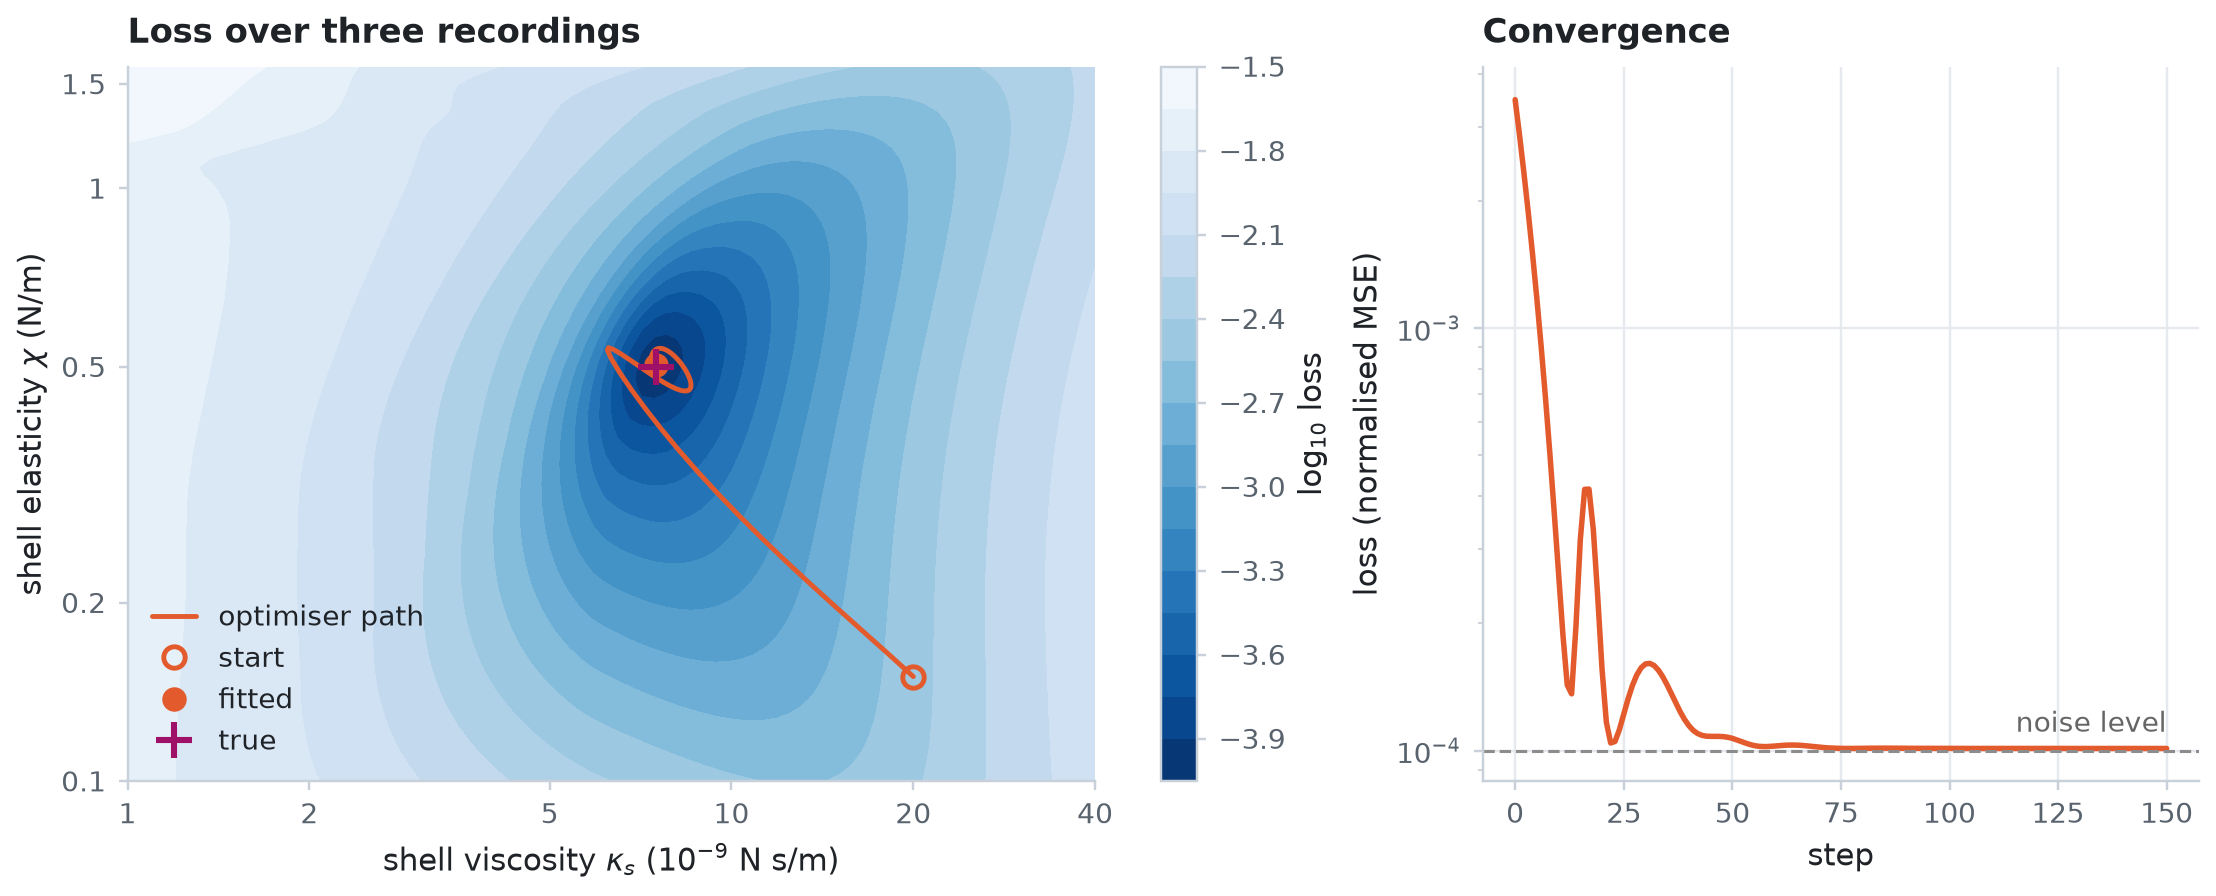

In [6]:
fig, (ax_l, ax_h) = plt.subplots(
    1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [1.35, 1]}
)
# Plot kappa_s in units of 1e-9 N s/m.
contours = ax_l.contourf(
    np.asarray(search_space["kappa_s"]) * 1e9,
    np.asarray(search_space["chi"]),
    np.log10(landscape),
    levels=20,
    cmap="Blues_r",
)
fig.colorbar(contours, ax=ax_l, label="log$_{10}$ loss")
ax_l.set_xscale("log")
ax_l.set_yscale("log")
ax_l.minorticks_off()
ax_l.set_xticks([1, 2, 5, 10, 20, 40], labels=["1", "2", "5", "10", "20", "40"])
ax_l.set_yticks([0.1, 0.2, 0.5, 1.0, 1.5], labels=["0.1", "0.2", "0.5", "1", "1.5"])
ax_l.grid(False)
ax_l.plot(path[:, 1] * 1e9, path[:, 0], color="C1", lw=1.6, label="optimiser path")
ax_l.plot(
    path[0, 1] * 1e9,
    path[0, 0],
    "o",
    ms=7,
    mfc="none",
    mec="C1",
    mew=1.6,
    label="start",
)
ax_l.plot(path[-1, 1] * 1e9, path[-1, 0], "o", ms=7, color="C1", label="fitted")
ax_l.plot(
    TRUE["kappa_s"] * 1e9, TRUE["chi"], "+", ms=12, mew=2, color="C3", label="true"
)
ax_l.set_xlabel(r"shell viscosity $\kappa_s$ ($10^{-9}$ N s/m)")
ax_l.set_ylabel(r"shell elasticity $\chi$ (N/m)")
ax_l.set_title("Loss over three recordings")
ax_l.legend(loc="lower left")

ax_h.semilogy(fit.loss_history, color="C1")
ax_h.axhline((NOISE / R0) ** 2, color="0.55", lw=1.0, ls="--")
ax_h.annotate(
    "noise level",
    xy=(len(fit.loss_history) - 1, (NOISE / R0) ** 2),
    xytext=(0, 4),
    textcoords="offset points",
    ha="right",
    va="bottom",
    color="0.4",
    fontsize=9,
)
ax_h.set_xlabel("step")
ax_h.set_ylabel("loss (normalised MSE)")
ax_h.set_title("Convergence")
plt.show()

The valley is longer along `chi` than along `kappa_s`, so these recordings pin down the viscosity more tightly than the elasticity. The path overshoots and circles the minimum before the decaying learning rate lets it settle.

## Compare the fitted curves with the data

`fit.result` holds one `SimulationResult` per recording, simulated with the fitted parameters.

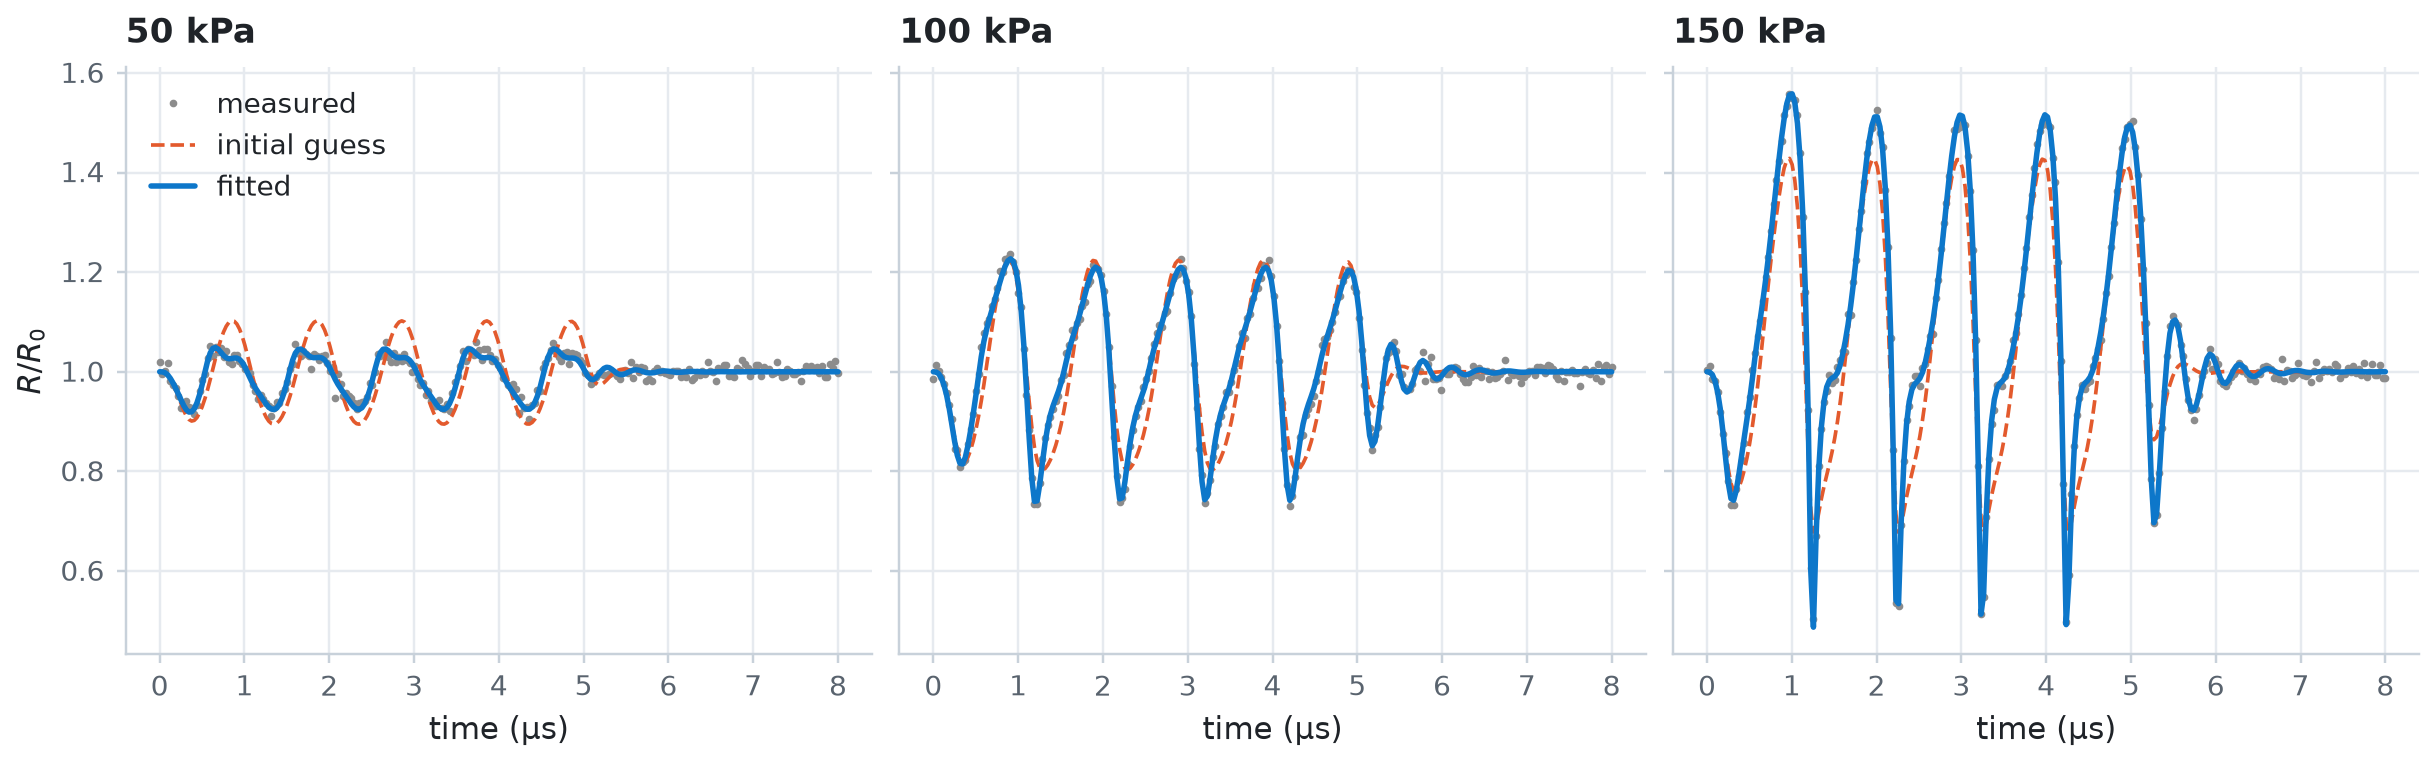

In [7]:
guess = {name: p.value for name, p in params0.items()}
fig, axes = plt.subplots(1, len(PRESSURES), figsize=(11, 3.4), sharey=True)
for ax, condition, result in zip(axes, conditions, fit.result, strict=True):
    t_us = np.asarray(result.ts) * 1e6
    initial = run_simulation(
        *make_model(guess, condition), save_spec=SAVE_SPEC, t_max=T_MAX
    ).radius
    ax.plot(t_us, condition["radius"] / R0, ".", ms=3, color="0.55", label="measured")
    ax.plot(t_us, initial / R0, color="C1", lw=1.2, ls="--", label="initial guess")
    ax.plot(t_us, result.radius / R0, color="C0", label="fitted")
    ax.set_title(f"{condition['pressure'] / 1e3:.0f} kPa")
    ax.set_xlabel("time (µs)")
axes[0].set_ylabel(r"$R/R_0$")
axes[0].legend(loc="upper left")
plt.show()

## Fit other kinds of data

`loss_fn` receives the full simulation result, so the same recipe fits any differentiable quantity:

- **Hydrophone signals.** Compute the radiated pressure inside `loss_fn` with an emission model such as [`IncompressibleMonopole`](https://imperial-nsb.github.io/jbubble/api/acoustics/#jbubble.acoustics.emission.IncompressibleMonopole), and compare it with the measured signal with [`normalised_mse_emission`](https://imperial-nsb.github.io/jbubble/api/metrics/#jbubble.metrics.normalised_mse_emission).
- **Camera frames at their own times.** Interpolate the simulated radius onto the frame times with `jnp.interp`.
- **Per-bubble values.** Fit each bubble's own `R0` with an array `Parameter` and an index in each condition.

The [fitting guide](https://imperial-nsb.github.io/jbubble/guide/fitting/) shows each of these, plus Levenberg-Marquardt fits and uncertainty estimates. To learn a whole surface-tension law instead of two numbers, see example 11.